In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/creditcardfraud/creditcard.csv


Install required libaries.

Import required libaries.

In [2]:
# import data science libraries
import pandas as pd
import numpy as np
import math


# import pytorch libraries
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

# import utility libraries
from tqdm import tqdm
from datetime import datetime

# import visualisation libraries
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, recall_score
from sklearn.preprocessing import QuantileTransformer


In [3]:
import os
import pandas as pd

if os.path.exists("/kaggle/input/creditcardfraud/creditcard.csv"):
    data_path = "/kaggle/input/creditcardfraud/creditcard.csv"
else:
    data_path = "./data/creditcard.csv"

df = pd.read_csv(data_path)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# from sklearn.model_selection import train_test_split

# # 전체 데이터에서 5%만 사용 (테스트용)
# df_small, _ = train_test_split(
#     df,
#     test_size=0.95,             
#     stratify=df["Class"],        
#     random_state=42
# )

# print("Small DF shape:", df_small.shape)
# print("Fraud ratio:", df_small["Class"].mean())

In [5]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df["Class"], random_state=42
)
# train_df, test_df = train_test_split(
#     df_small, test_size=0.2, stratify=df_small["Class"], random_state=42
# )
train_base, val_df = train_test_split(
    train_df, test_size=0.2, stratify=train_df["Class"], random_state=42
)

In [6]:
# ===== XGBoost imbalance weight =====
# scale_pos_weight = (
#     train_base["Class"].value_counts()[0] /
#     train_base["Class"].value_counts()[1]
# )
scale_pos_weight = (
    train_df["Class"].value_counts()[0] /
    train_df["Class"].value_counts()[1]
)

print("scale_pos_weight:", scale_pos_weight)

XGB_PARAMS_BASE = dict(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

XGB_PARAMS_ON  = {**XGB_PARAMS_BASE, "scale_pos_weight": scale_pos_weight}
XGB_PARAMS_OFF = {**XGB_PARAMS_BASE}

def make_hybrid(real_df, syn_df):
    return pd.concat([real_df, syn_df], axis=0)\
             .sample(frac=1, random_state=42)\
             .reset_index(drop=True)

scale_pos_weight: 577.2868020304569


In [7]:
def find_best_threshold(prob, y_true):
    thresholds = np.linspace(0.001, 0.5, 200)
    best_t, best_f1 = 0.5, 0
    for t in thresholds:
        pred = (prob > t).astype(int)
        f1 = f1_score(y_true, pred)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


In [8]:
def class_ratio_cols(df, prefix="train"):
    counts = df["Class"].value_counts().to_dict()
    n0 = int(counts.get(0, 0))
    n1 = int(counts.get(1, 0))
    total = n0 + n1
    return {
        f"{prefix}_n": total,
        f"{prefix}_n0": n0,
        f"{prefix}_n1": n1,
        f"{prefix}_p0": (n0 / total) if total else np.nan,
        f"{prefix}_p1": (n1 / total) if total else np.nan,
    }

In [9]:
def evaluate_holdout_xgb(train_any_df, val_df, test_df, xgb_params):

    X_train = train_any_df.drop(columns=["Class"])
    y_train = train_any_df["Class"]

    X_val = val_df.drop(columns=["Class"])
    y_val = val_df["Class"]

    X_test = test_df.drop(columns=["Class"])
    y_test = test_df["Class"]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)
    X_test_s  = scaler.transform(X_test)
    # scaler = QuantileTransformer(
    # n_quantiles=1000,
    # output_distribution="normal",
    # random_state=42
    # )
    
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)
    X_test_s  = scaler.transform(X_test)

    model = XGBClassifier(**xgb_params)
    model.fit(X_train_s, y_train)

    val_prob = model.predict_proba(X_val_s)[:, 1]
    best_t, best_f1 = find_best_threshold(val_prob, y_val)

    test_prob = model.predict_proba(X_test_s)[:, 1]

    pred_fixed = (test_prob > 0.5).astype(int)
    pred_opt   = (test_prob > best_t).astype(int)

    return {
        "ROC-AUC": roc_auc_score(y_test, test_prob),
        "AUPRC": average_precision_score(y_test, test_prob),
        "F1@0.5": f1_score(y_test, pred_fixed),
        "Recall@0.5": recall_score(y_test, pred_fixed),
        "F1@opt": f1_score(y_test, pred_opt),
        "Recall@opt": recall_score(y_test, pred_opt),
        "Best_threshold": best_t,
        "Best_F1_on_VAL": best_f1,
        "test_prob": test_prob,
    }

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def get_cm_and_class_f1(y_true, y_pred):
    # labels=[1,0] => 행/열 순서: Fraud(1) -> Legit(0)
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
    f1_fraud = f1_score(y_true, y_pred, pos_label=1)
    f1_legit = f1_score(y_true, y_pred, pos_label=0)
    return cm, f1_fraud, f1_legit

def plot_cm(cm, title):
    plt.figure(figsize=(5,4), dpi=150)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Fraudulent", "Legitimate"],
        yticklabels=["Fraudulent", "Legitimate"],
        cbar_kws={"label": "Count"},
        linewidths=1,
        linecolor="white"
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [11]:
# set random seed
seed = 1234


# set number of neurons per layer
mlp_layers = [1024, 1024, 1024, 1024]

# set non-linear activation function
activation = 'lrelu'

# set number of diffusion steps
diffusion_steps = 500

# set diffusion start and end betas
diffusion_beta_start = 1e-4
diffusion_beta_end = 0.02

# set diffusion scheduler
scheduler = 'linear'

# set number of training epochs
epochs = 500

# set training batch size
batch_size = 512

# set training learning rate
learning_rate = 1e-4

# set the device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [12]:
# set numpy seed
np.random.seed(seed)

# set pytorch seed
torch.manual_seed(seed)

# set cuda seed
torch.cuda.manual_seed(seed)

In [13]:
# from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer

FEATURE_COLS = [c for c in df.columns if c != "Class"]
#FEATURE_COLS = [c for c in df_small.columns if c != "Class"]


diff_scaler = StandardScaler()
X_train = diff_scaler.fit_transform(train_base[FEATURE_COLS])
# diff_scaler = QuantileTransformer(
#     n_quantiles=1000,
#     output_distribution="normal",   # 보통 fraud 데이터에 좋음
#     random_state=seed
# )

X_train = diff_scaler.fit_transform(train_base[FEATURE_COLS])

train_x = torch.FloatTensor(X_train)
train_y = torch.LongTensor(train_base["Class"].values.astype(int))

train_set = TensorDataset(train_x, train_y)
dataloader = DataLoader(train_set, batch_size=batch_size, shuffle=True)


In [14]:
# define base feedforward network
class BaseNetwork(nn.Module):

    # define base network constructor
    def __init__(self, hidden_size, activation='lrelu'):

        # call super calass constructor 
        super(BaseNetwork, self).__init__()

        # init 
        self.layers = self.init_layers(hidden_size)

        # case: lrelu activation
        if activation == 'lrelu':

            # set lrelu activation
            self.activation = nn.LeakyReLU(negative_slope=0.4, inplace=True)

        # case: relu activation
        elif activation == 'relu':

            # set relu activation
            self.activation = nn.ReLU(inplace=True)

        # case: tanh activation
        elif activation == 'tanh':

            # set tanh activation
            self.activation = nn.Tanh()

        # case: sigmoid activation
        else:

            # set sigmoid activation
            self.activation = nn.Sigmoid()

    # define layer initialization 
    def init_layers(self, layer_dimensions):

        # init layers
        layers = []

        # iterate over layer dimensions 
        for i in range(len(layer_dimensions)-1):

            # init linear layer 
            layer = nn.Linear(layer_dimensions[i], layer_dimensions[i + 1], bias=True)
            
            # init linear layer weights
            nn.init.xavier_uniform_(layer.weight)
            
            # init linear layer bias
            nn.init.constant_(layer.bias, 0.0)

            # collecet linear layer 
            layers.append(layer)
            
            # register linear layer parameters
            self.add_module('linear_' + str(i), layer)

        # return layers
        return layers

    # define forward pass
    def forward(self, x):

        # iterate over layers
        for i in range(len(self.layers)):

            # run layer forward pass 
            x = self.activation(self.layers[i](x))

        # return forward pass result
        return x

In [15]:
ratios = [0.3, 0.5, 0.7, 1.0]

# define MLP synthesizer network
class MLPSynthesizer(nn.Module):
    def __init__(self, d_in, hidden_layers, dim_t=64, activation='lrelu', n_classes=2):
        super().__init__()

        self.dim_t = dim_t

        self.backbone = BaseNetwork([dim_t, *hidden_layers], activation=activation)

        self.label_embedding = nn.Embedding(n_classes, dim_t)

        self.projection = nn.Sequential(
            nn.Linear(d_in, dim_t),
            nn.SiLU(),
            nn.Linear(dim_t, dim_t)
        )

        self.time_embed = nn.Sequential(
            nn.Linear(dim_t, dim_t),
            nn.SiLU(),
            nn.Linear(dim_t, dim_t)
        )

        self.head = nn.Linear(hidden_layers[-1], d_in)

    def embed_time(self, timesteps, dim_out, max_period=10000):
        half = dim_out // 2
        freqs = torch.exp(-math.log(max_period) * torch.arange(half) / half).to(timesteps.device)
        args = timesteps[:, None].float() * freqs[None]
        emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        if dim_out % 2:
            emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=-1)
        return emb

    def forward(self, x, timesteps, label):
        time_emb = self.embed_time(timesteps, self.dim_t)
        time_emb = self.time_embed(time_emb)

        time_label_emb = time_emb + self.label_embedding(label)

        x = self.projection(x)
        x = x + time_label_emb
        x = self.backbone(x)
        return self.head(x)


Init and set experiment parameters.

In [16]:
# define BaseDiffuser network
class BaseDiffuser(object):

    # define base diffuser network constructor
    def __init__(
            self, 
            total_steps=1000, 
            beta_start=1e-4, 
            beta_end=0.02, 
            device='cpu',
            scheduler='linear'
        ):

        # set diffusion steps
        self.total_steps = total_steps

        # set diffusion start beta
        self.beta_start = beta_start

        # set diffusion end beta
        self.beta_end = beta_end

        # set compute device
        self.device = device

        # set noise schedule alphas and betas
        self.alphas, self.betas = self.prepare_noise_schedule(scheduler=scheduler)

        # set noise schedule alhpa hats
        self.alphas_hat = torch.cumprod(self.alphas, dim=0)

    # define noise schedule
    def prepare_noise_schedule(self, scheduler: str):

        # determine noise scheduler scale
        scale = 1000 / self.total_steps

        # scale beta start
        beta_start = scale * self.beta_start

        # scale beta end
        beta_end = scale * self.beta_end

        # case: linear noise scheduler
        if scheduler == 'linear':

            # determine linear noise schedule betas
            betas = torch.linspace(beta_start, beta_end, self.total_steps)

            # determine linear noise schedule alphas
            alphas = 1.0 - betas

        # case: quadratic noise scheduler
        elif scheduler == 'quad':

            # determine quadratic noise schedule betas
            betas = torch.linspace(self.beta_start ** 0.5, self.beta_end ** 0.5, self.total_steps) ** 2

            # determine quadratic noise schedule alphas 
            alphas = 1.0 - betas

        # return noise scheduler alphas and betas
        return alphas.to(self.device), betas.to(self.device)

    # define random timesteps sampler 
    def sample_random_timesteps(self, n: int):

        # sample random timesteps
        t = torch.randint(low=1, high=self.total_steps, size=(n,), device=self.device)

        # return random timesteps
        return t

    # define gaussian noise addition
    def add_gauss_noise(self, x_num, t):

        # determine noise alpha hat
        sqrt_alpha_hat = torch.sqrt(self.alphas_hat[t])[:, None]

        # determine noise one minius alpha hat 
        sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alphas_hat[t])[:, None]

        # determine numeric noise
        noise_num = torch.randn_like(x_num)

        # determine x numeric noise
        x_noise_num = sqrt_alpha_hat * x_num + sqrt_one_minus_alpha_hat * noise_num

        # return x numeric noise and numeric noise
        return x_noise_num, noise_num

    # define gaussian noise sampling
    def p_sample_gauss(self, model_out, z_norm, timesteps):

        # determine noise alpha hat
        sqrt_alpha_t = torch.sqrt(self.alphas[timesteps])[:, None]

        # determine noise betas
        betas_t = self.betas[timesteps][:, None]
        
        # determine noise one minius alpha hat 
        sqrt_one_minus_alpha_hat_t = torch.sqrt(1 - self.alphas_hat[timesteps])[:, None]
        
        epsilon_t = torch.sqrt(self.betas[timesteps][:, None])

        # determine random noise
        random_noise = torch.randn_like(z_norm)
        random_noise[timesteps == 0] = 0.0

        # determine model mean
        model_mean = ((1 / sqrt_alpha_t) * (z_norm - (betas_t * model_out / sqrt_one_minus_alpha_hat_t)))

        # determine z norm
        z_norm = model_mean + (epsilon_t * random_noise)

        # return z norm
        return z_norm

In [17]:
# initialize the FinDiff synthesizer model 
d_in = len(FEATURE_COLS)  # 30
synthesizer_model = MLPSynthesizer(
    d_in=d_in,
    hidden_layers=mlp_layers,
    activation=activation,
    n_classes=2
).to(device)

In [18]:
# initialize the FinDiff base diffuser model
diffuser_model = BaseDiffuser(
    total_steps=diffusion_steps,
    beta_start=diffusion_beta_start,
    beta_end=diffusion_beta_end,
    scheduler=scheduler,
    device=device
)

In [19]:
# init learning rate scheduler
optimizer = optim.Adam(synthesizer_model.parameters(), lr=learning_rate)
lr_scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

# int mean-squared-error loss
loss_fnc = nn.MSELoss()

In [20]:
train_epoch_losses = []

synthesizer_model = synthesizer_model.to(device)
synthesizer_model.train()

pbar = tqdm(range(epochs))

for epoch in pbar:

    batch_losses = []

    for batch_x, batch_y in dataloader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        t = diffuser_model.sample_random_timesteps(batch_x.size(0))

        x_t, noise = diffuser_model.add_gauss_noise(batch_x, t)

        pred_noise = synthesizer_model(x_t, t, batch_y)

        loss = loss_fnc(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    lr_scheduler.step()

    batch_losses_mean = np.mean(batch_losses)
    train_epoch_losses.append(batch_losses_mean)

    pbar.set_description(f"[Epoch {epoch:03d}] train_loss={batch_losses_mean:.6f}")


[Epoch 499] train_loss=0.118892: 100%|██████████| 500/500 [20:41<00:00,  2.48s/it]



[Diffusion] ratio = natural
[natural | syn_only_spw_ON] thr=0.297 | Fraud F1=0.7421 | Legit F1=0.9995


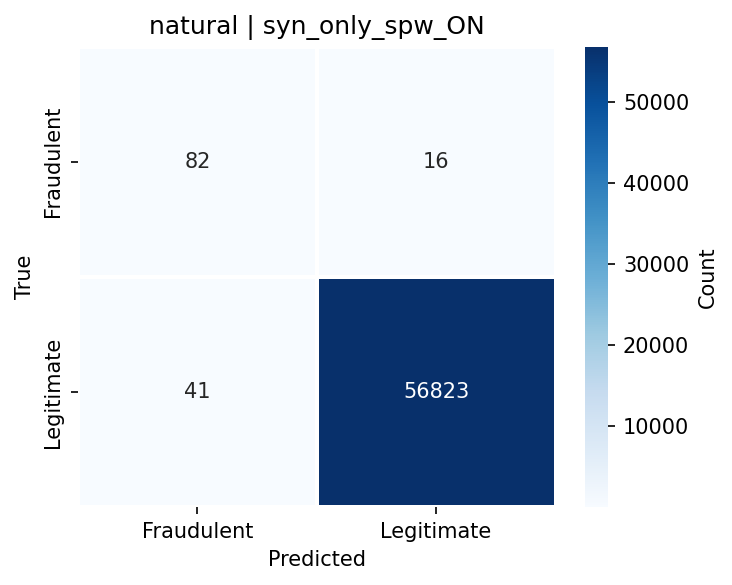

[natural | syn_only_spw_OFF] thr=0.249 | Fraud F1=0.7736 | Legit F1=0.9996


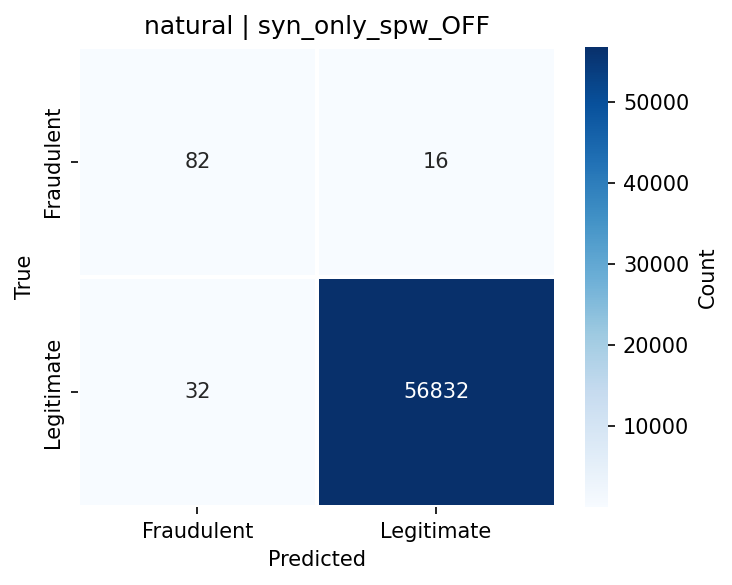

[natural | hybrid_spw_ON] thr=0.445 | Fraud F1=0.8293 | Legit F1=0.9997


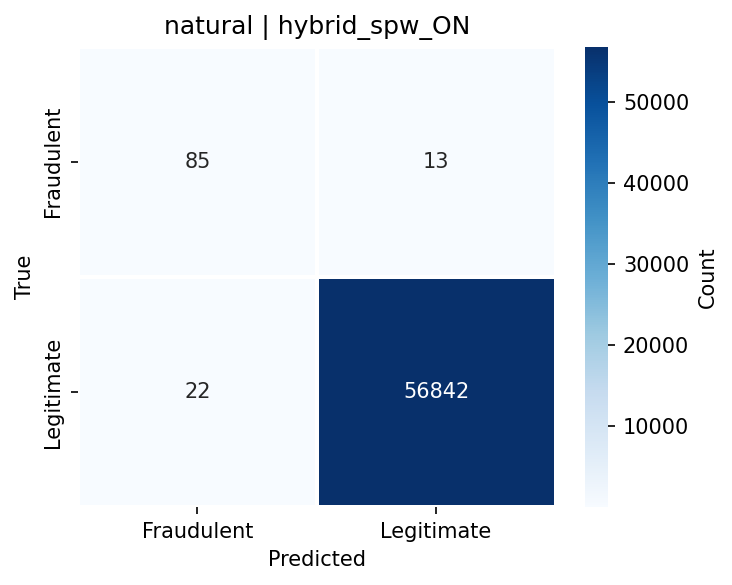

[natural | hybrid_spw_OFF] thr=0.299 | Fraud F1=0.8601 | Legit F1=0.9998


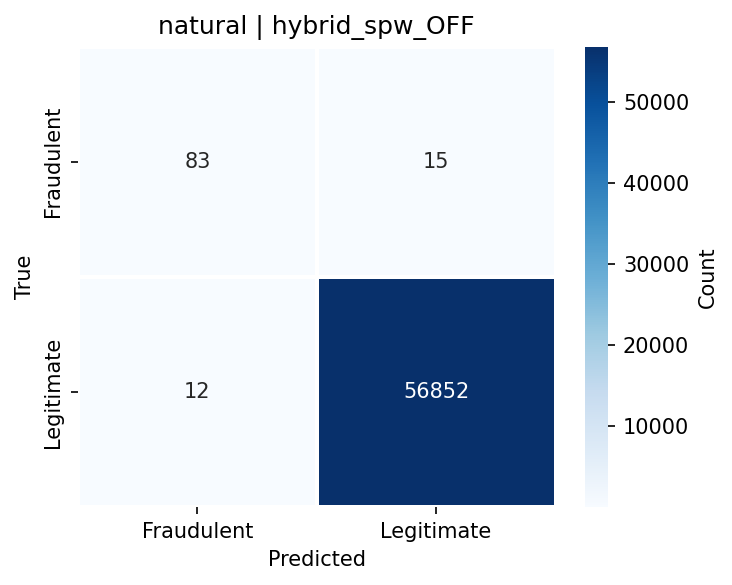


[Diffusion] ratio = forced_0.30
[forced_0.30 | syn_only_spw_ON] thr=0.500 | Fraud F1=0.0164 | Legit F1=0.8858


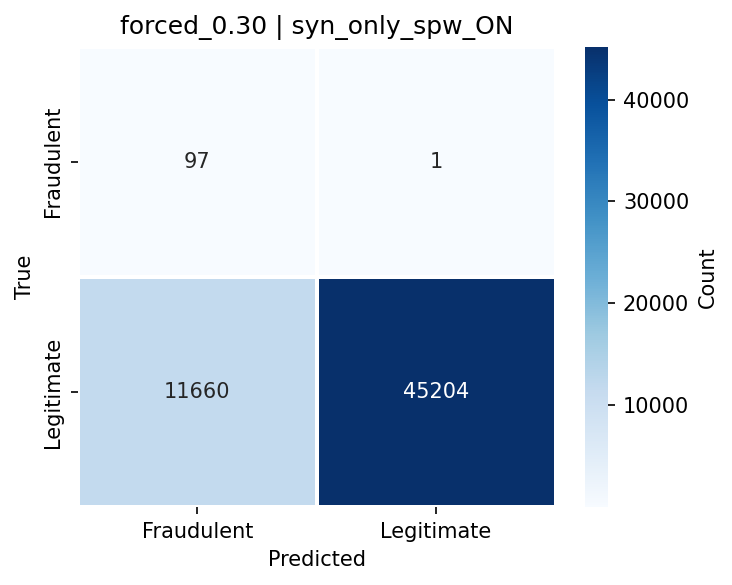

[forced_0.30 | syn_only_spw_OFF] thr=0.500 | Fraud F1=0.1971 | Legit F1=0.9937


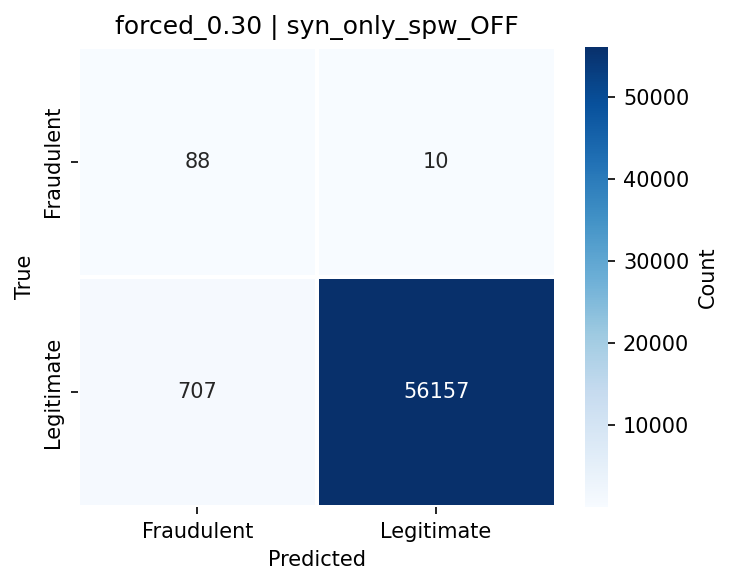

[forced_0.30 | hybrid_spw_ON] thr=0.500 | Fraud F1=0.0237 | Legit F1=0.9277


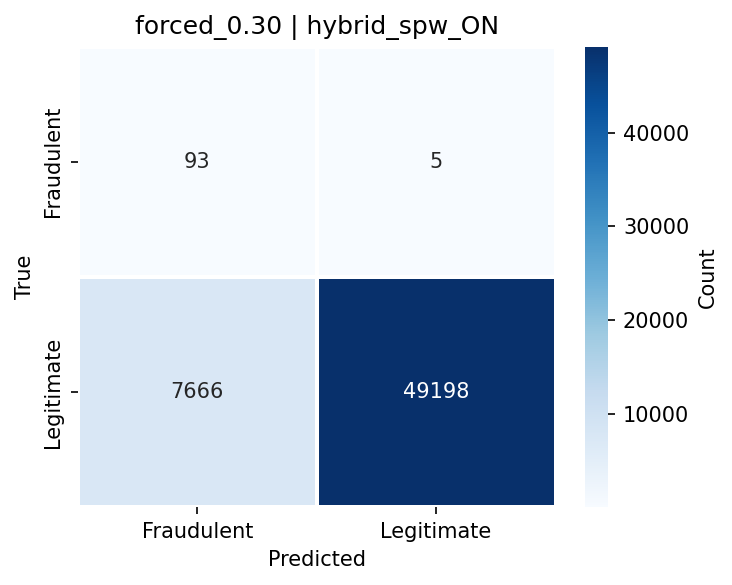

[forced_0.30 | hybrid_spw_OFF] thr=0.497 | Fraud F1=0.4628 | Legit F1=0.9982


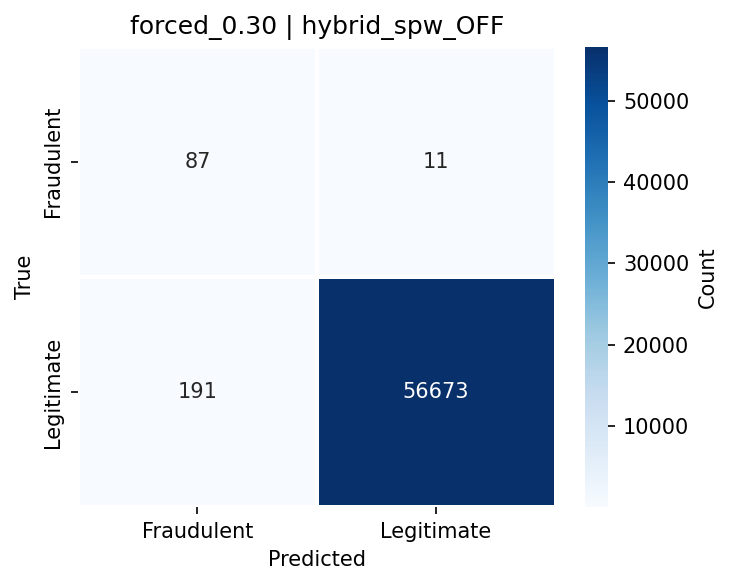


[Diffusion] ratio = forced_0.50
[forced_0.50 | syn_only_spw_ON] thr=0.500 | Fraud F1=0.0116 | Legit F1=0.8341


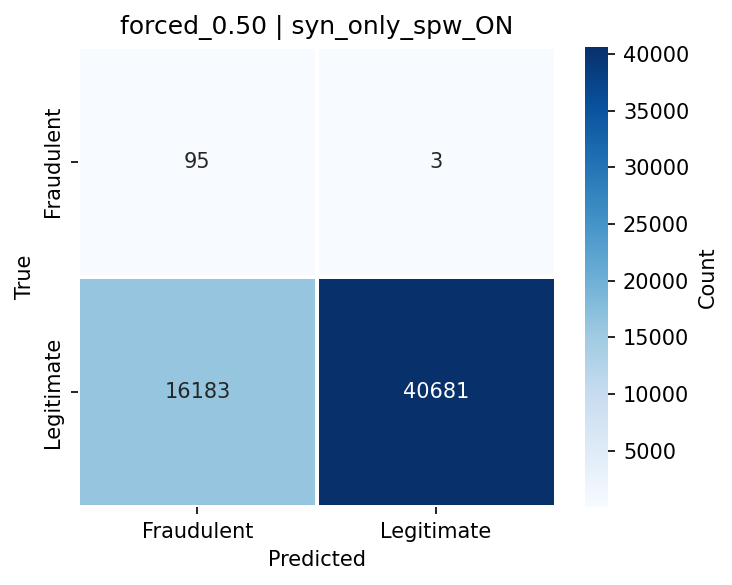

[forced_0.50 | syn_only_spw_OFF] thr=0.500 | Fraud F1=0.1178 | Legit F1=0.9880


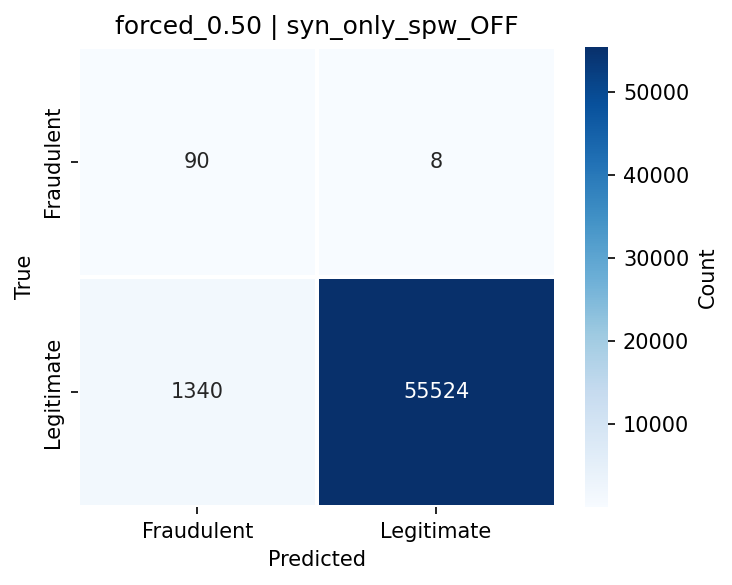

[forced_0.50 | hybrid_spw_ON] thr=0.500 | Fraud F1=0.0164 | Legit F1=0.8899


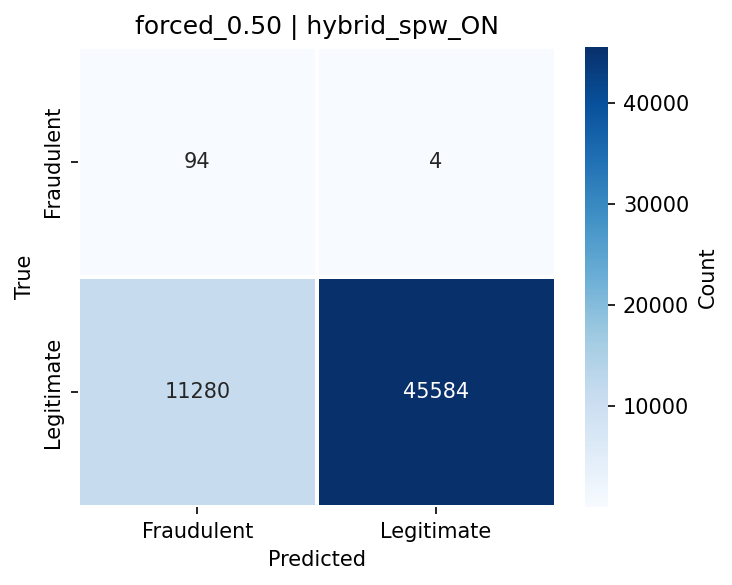

[forced_0.50 | hybrid_spw_OFF] thr=0.497 | Fraud F1=0.3365 | Legit F1=0.9969


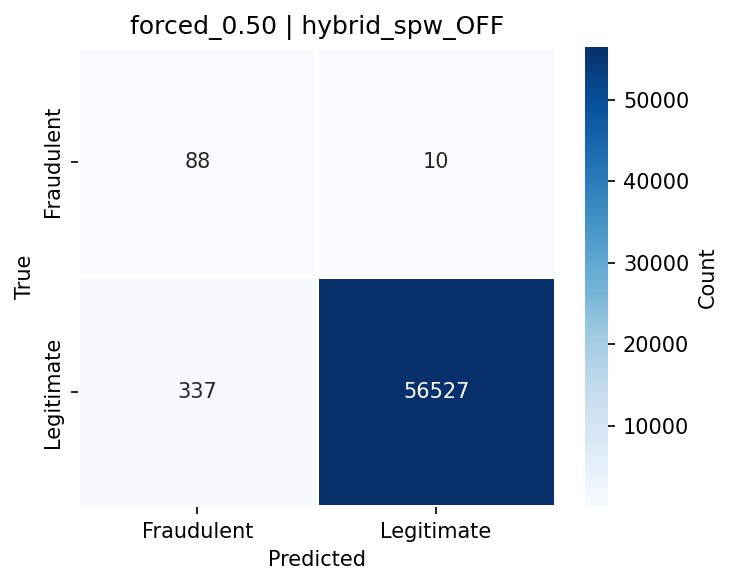


[Diffusion] ratio = forced_0.70
[forced_0.70 | syn_only_spw_ON] thr=0.500 | Fraud F1=0.0095 | Legit F1=0.7817


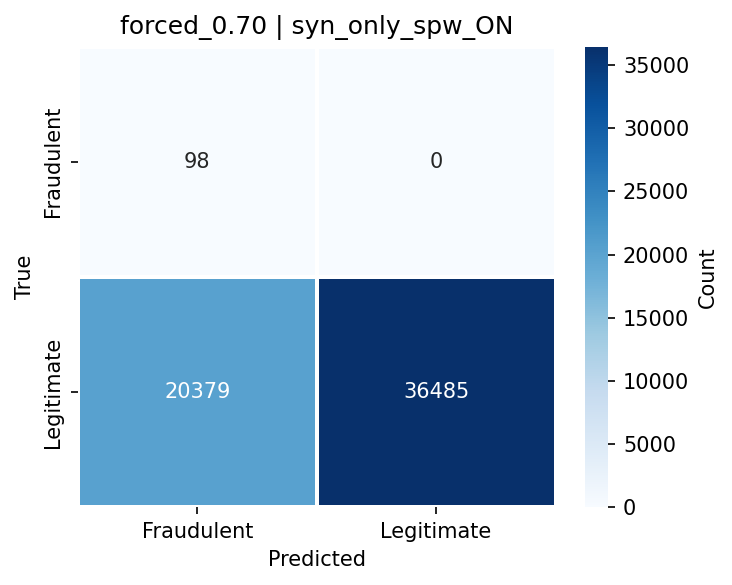

[forced_0.70 | syn_only_spw_OFF] thr=0.500 | Fraud F1=0.0670 | Legit F1=0.9772


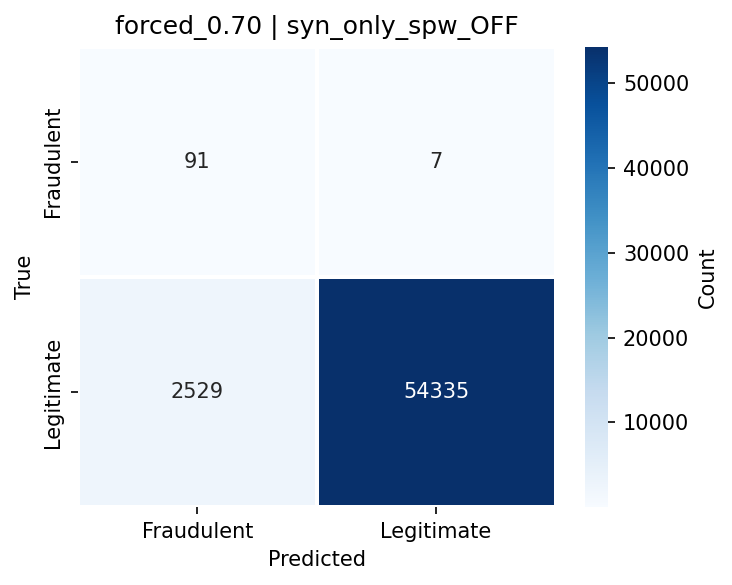

[forced_0.70 | hybrid_spw_ON] thr=0.500 | Fraud F1=0.0143 | Legit F1=0.8650


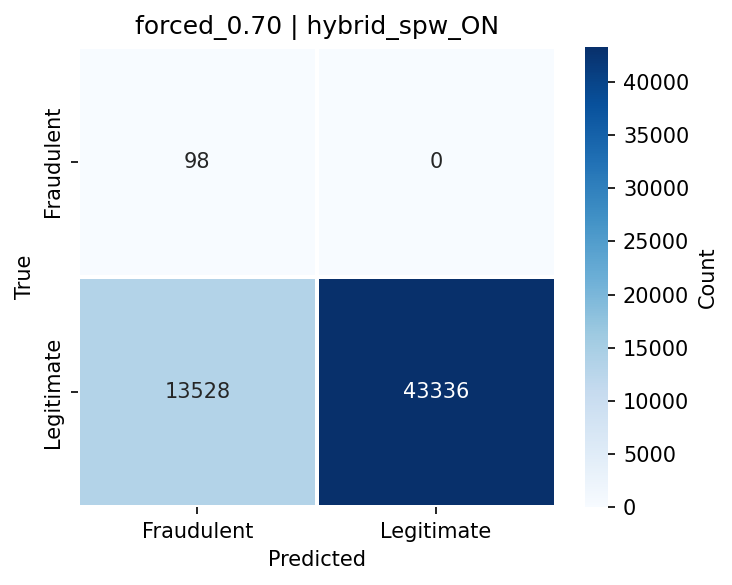

[forced_0.70 | hybrid_spw_OFF] thr=0.500 | Fraud F1=0.2631 | Legit F1=0.9956


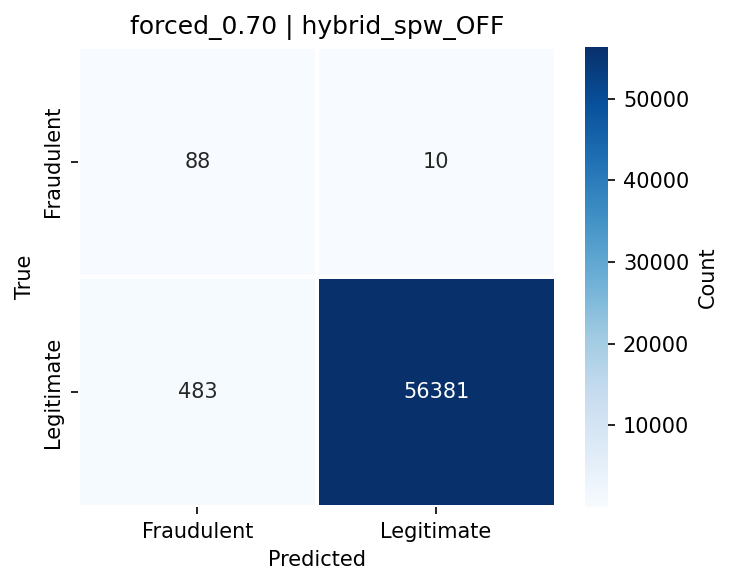


[Diffusion] ratio = forced_1.00
  -> skip syn-only (only one class in syn): [1]
[forced_1.00 | hybrid_spw_ON] thr=0.500 | Fraud F1=0.0111 | Legit F1=0.8212


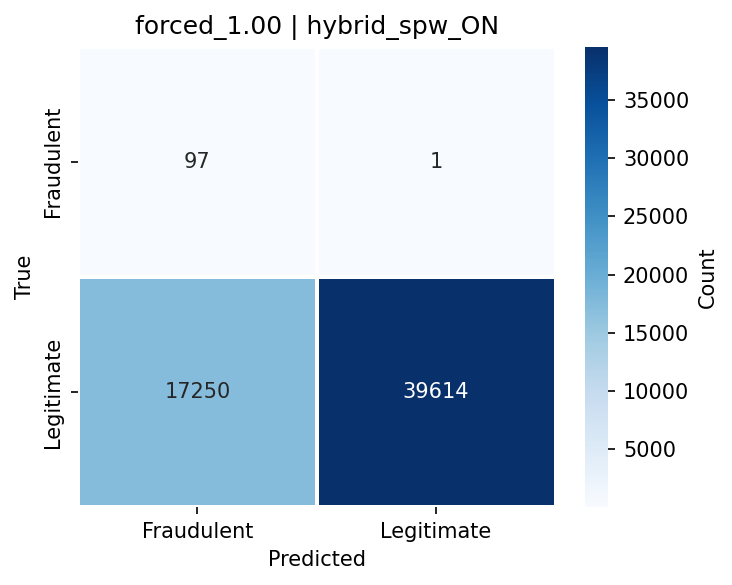

[forced_1.00 | hybrid_spw_OFF] thr=0.500 | Fraud F1=0.1731 | Legit F1=0.9926


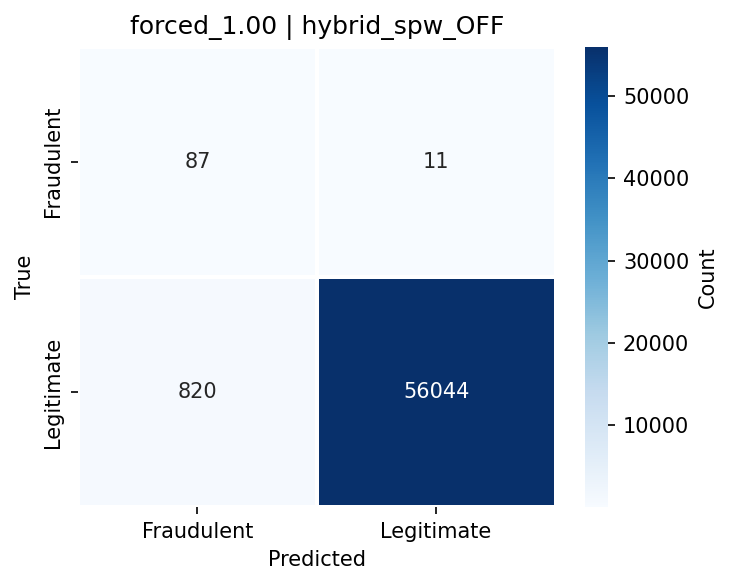

ROC-AUC     AUPRC  F1_fraud  F1_legit  \
syn_ratio   train_setting                                              
forced_0.30 hybrid_spw_OFF    0.985086  0.808673  0.462766  0.998221   
            hybrid_spw_ON     0.979571  0.763735  0.023673  0.927678   
            syn_only_spw_OFF  0.988024  0.746837  0.197088  0.993657   
            syn_only_spw_ON   0.988033  0.669358  0.016364  0.885754   
forced_0.50 hybrid_spw_OFF    0.983468  0.811924   0.33652   0.99694   
            hybrid_spw_ON     0.984782  0.784942  0.016388  0.889861   
            syn_only_spw_OFF  0.987404  0.765217  0.117801  0.988007   
            syn_only_spw_ON   0.983815  0.704923  0.011602  0.834071   
forced_0.70 hybrid_spw_OFF    0.985376  0.805271  0.263079  0.995647   
            hybrid_spw_ON     0.988709  0.738403  0.014282   0.86499   
            syn_only_spw_OFF  0.988265  0.776736  0.066961  0.977195   
            syn_only_spw_ON   0.990883  0.686539  0.009526   0.78169   
forced_1.00 hybrid_spw_OFF    0.977132   0.79864  0.173134  0.992641   
            hybrid_spw_ON     0.982658    0.8058  0.011121  0.821194   
natural     hybrid_spw_OFF    0.978017  0.872985  0.860104  0.999763   
            hybrid_spw_ON     0.979233  0.873741  0.829268  0.999692   
            syn_only_spw_OFF  0.963281  0.724658  0.773585  0.999578   
            syn_only_spw_ON   0.973218  0.745546  0.742081  0.999499   

                                F1@0.5 Recall@0.5    F1@opt Recall@opt  \
syn_ratio   train_setting                                                
forced_0.30 hybrid_spw_OFF       0.464   0.887755  0.462766   0.887755   
            hybrid_spw_ON     0.023673    0.94898  0.023673    0.94898   
            syn_only_spw_OFF  0.197088   0.897959  0.197088   0.897959   
            syn_only_spw_ON   0.016364   0.989796  0.016364   0.989796   
forced_0.50 hybrid_spw_OFF    0.339114   0.897959   0.33652   0.897959   
            hybrid_spw_ON     0.016388   0.959184  0.016388   0.959184   
            syn_only_spw_OFF  0.117801   0.918367  0.117801   0.918367   
            syn_only_spw_ON   0.011602   0.969388  0.011602   0.969388   
forced_0.70 hybrid_spw_OFF    0.263079   0.897959  0.263079   0.897959   
            hybrid_spw_ON     0.014282        1.0  0.014282        1.0   
            syn_only_spw_OFF  0.066961   0.928571  0.066961   0.928571   
            syn_only_spw_ON   0.009526        1.0  0.009526        1.0   
forced_1.00 hybrid_spw_OFF    0.173134   0.887755  0.173134   0.887755   
            hybrid_spw_ON     0.011121   0.989796  0.011121   0.989796   
natural     hybrid_spw_OFF    0.873684   0.846939  0.860104   0.846939   
            hybrid_spw_ON     0.823529   0.857143  0.829268   0.867347   
            syn_only_spw_OFF  0.790244   0.826531  0.773585   0.836735   
            syn_only_spw_ON   0.762791   0.836735  0.742081   0.836735   

                             Best_threshold  train_p0  train_p1  test_p0  \
syn_ratio   train_setting                                                  
forced_0.30 hybrid_spw_OFF         0.497492  0.849138  0.150862  0.99828   
            hybrid_spw_ON               0.5  0.849138  0.150862  0.99828   
            syn_only_spw_OFF            0.5  0.700004  0.299996  0.99828   
            syn_only_spw_ON             0.5  0.700004  0.299996  0.99828   
forced_0.50 hybrid_spw_OFF         0.497492  0.749136  0.250864  0.99828   
            hybrid_spw_ON               0.5  0.749136  0.250864  0.99828   
            syn_only_spw_OFF            0.5       0.5       0.5  0.99828   
            syn_only_spw_ON             0.5       0.5       0.5  0.99828   
forced_0.70 hybrid_spw_OFF              0.5  0.649136  0.350864  0.99828   
            hybrid_spw_ON               0.5  0.649136  0.350864  0.99828   
            syn_only_spw_OFF            0.5  0.300001  0.699999  0.99828   
            syn_only_spw_ON             0.5  0.300001  0.699999  0.99828   
forced_1.00 hybrid_spw_OFF              0.5  

In [21]:
from sklearn.metrics import pairwise_distances
import numpy as np
# Diffusion Sampling (ratio-controlled)
def sample_diffusion_ratio(model, diffuser, diff_scaler, n, d_in, feature_cols, ratio=None, device=None):
    """
    ratio=None -> natural (train_base의 fraud 비율 사용)
    ratio=float -> forced (원하는 fraud 비율로 라벨 강제)
    """
    model.eval()
    if device is None:
        device = next(model.parameters()).device

    if ratio is None:
        p_fraud = float(train_base["Class"].mean())
        labels = (np.random.rand(n) < p_fraud).astype(int)
    else:
        n_fraud = int(n * ratio)
        n_legit = n - n_fraud
        labels = np.array([1]*n_fraud + [0]*n_legit)
        np.random.shuffle(labels)

    labels_t = torch.LongTensor(labels).to(device)

    # ---- reverse diffusion ----
    x = torch.randn((n, d_in), device=device)

    with torch.no_grad():
        for step in reversed(range(diffuser.total_steps)):
            t = torch.full((n,), step, dtype=torch.long, device=device)
            eps = model(x, t, labels_t)
            x = diffuser.p_sample_gauss(eps, x, t)

    x = diff_scaler.inverse_transform(x.cpu().numpy())
    syn_df = pd.DataFrame(x, columns=feature_cols)
    syn_df["Class"] = labels
    return syn_df

def privacy_nn_memorization(real_df, syn_df, feature_cols, threshold=1e-6,
                            sample_real=5000, sample_syn=5000, seed=42):
    real_s = real_df.sample(n=min(sample_real, len(real_df)), random_state=seed)
    syn_s  = syn_df.sample(n=min(sample_syn, len(syn_df)), random_state=seed)

    real_X = real_s[feature_cols].values
    syn_X  = syn_s[feature_cols].values

    dists = pairwise_distances(syn_X, real_X, metric="euclidean")
    min_dists = dists.min(axis=1)

    out = {
        "NN_mean": float(min_dists.mean()),
        "NN_min": float(min_dists.min()),
        "NearDup_rate(thr)": float((min_dists < threshold).mean())
    }

    real_fraud = real_df[real_df.Class==1]
    syn_fraud  = syn_df[syn_df.Class==1]
    if len(real_fraud) > 0 and len(syn_fraud) > 0:
        rf = real_fraud.sample(n=min(2000, len(real_fraud)), random_state=seed)[feature_cols].values
        sf = syn_fraud.sample(n=min(2000, len(syn_fraud)), random_state=seed)[feature_cols].values
        d_f = pairwise_distances(sf, rf, metric="euclidean")
        min_d_f = d_f.min(axis=1)
        out["Fraud_NN_mean"] = float(min_d_f.mean())
        out["Fraud_NN_min"]  = float(min_d_f.min())
    else:
        out["Fraud_NN_mean"] = np.nan
        out["Fraud_NN_min"]  = np.nan

    return out

ratios_ext = [None] + ratios   # natural + forced list

diff_results = {}

test_ratio_cols = class_ratio_cols(test_df, "test")

for r in ratios_ext:
    ratio_name = "natural" if r is None else f"forced_{r:.2f}"
    print(f"\n[Diffusion] ratio = {ratio_name}")

    # synthetic gen
    syn = sample_diffusion_ratio(
        model=synthesizer_model,
        diffuser=diffuser_model,
        diff_scaler=diff_scaler,
        n=len(train_base),
        d_in=len(FEATURE_COLS),
        feature_cols=FEATURE_COLS,
        ratio=r,
        device=device
    )

    syn_ratio_cols = class_ratio_cols(syn, "syn")

    # SYN-ONLY
    uniq = np.unique(syn["Class"].values)
    if len(uniq) >= 2:
        train_ratio_cols = class_ratio_cols(syn, "train")

        # spw ON
        m_on = evaluate_holdout_xgb(syn, val_df, test_df, XGB_PARAMS_ON)
        diff_results[(ratio_name, "syn_only_spw_ON")] = {**m_on, **train_ratio_cols, **test_ratio_cols, **syn_ratio_cols}

        y_true = test_df["Class"].values
        y_pred_opt = (m_on["test_prob"] > m_on["Best_threshold"]).astype(int)
        cm, f1_fraud, f1_legit = get_cm_and_class_f1(y_true, y_pred_opt)

        print(f"[{ratio_name} | syn_only_spw_ON] thr={m_on['Best_threshold']:.3f} | Fraud F1={f1_fraud:.4f} | Legit F1={f1_legit:.4f}")
        plot_cm(cm, title=f"{ratio_name} | syn_only_spw_ON")

        diff_results[(ratio_name, "syn_only_spw_ON")].update({"F1_fraud": f1_fraud, "F1_legit": f1_legit})

        # spw OFF
        m_off = evaluate_holdout_xgb(syn, val_df, test_df, XGB_PARAMS_OFF)
        diff_results[(ratio_name, "syn_only_spw_OFF")] = {**m_off, **train_ratio_cols, **test_ratio_cols, **syn_ratio_cols}

        y_pred_opt = (m_off["test_prob"] > m_off["Best_threshold"]).astype(int)
        cm, f1_fraud, f1_legit = get_cm_and_class_f1(y_true, y_pred_opt)

        print(f"[{ratio_name} | syn_only_spw_OFF] thr={m_off['Best_threshold']:.3f} | Fraud F1={f1_fraud:.4f} | Legit F1={f1_legit:.4f}")
        plot_cm(cm, title=f"{ratio_name} | syn_only_spw_OFF")

        diff_results[(ratio_name, "syn_only_spw_OFF")].update({"F1_fraud": f1_fraud, "F1_legit": f1_legit})

    else:
        print(f"  -> skip syn-only (only one class in syn): {uniq}")

    # HYBRID
    hybrid_train = make_hybrid(train_base, syn)
    train_ratio_cols = class_ratio_cols(hybrid_train, "train")

    # spw ON
    m_on = evaluate_holdout_xgb(hybrid_train, val_df, test_df, XGB_PARAMS_ON)
    diff_results[(ratio_name, "hybrid_spw_ON")] = {**m_on, **train_ratio_cols, **test_ratio_cols, **syn_ratio_cols}

    y_true = test_df["Class"].values
    y_pred_opt = (m_on["test_prob"] > m_on["Best_threshold"]).astype(int)
    cm, f1_fraud, f1_legit = get_cm_and_class_f1(y_true, y_pred_opt)

    print(f"[{ratio_name} | hybrid_spw_ON] thr={m_on['Best_threshold']:.3f} | Fraud F1={f1_fraud:.4f} | Legit F1={f1_legit:.4f}")
    plot_cm(cm, title=f"{ratio_name} | hybrid_spw_ON")

    diff_results[(ratio_name, "hybrid_spw_ON")].update({"F1_fraud": f1_fraud, "F1_legit": f1_legit})

    # spw OFF
    m_off = evaluate_holdout_xgb(hybrid_train, val_df, test_df, XGB_PARAMS_OFF)
    diff_results[(ratio_name, "hybrid_spw_OFF")] = {**m_off, **train_ratio_cols, **test_ratio_cols, **syn_ratio_cols}

    y_pred_opt = (m_off["test_prob"] > m_off["Best_threshold"]).astype(int)
    cm, f1_fraud, f1_legit = get_cm_and_class_f1(y_true, y_pred_opt)

    print(f"[{ratio_name} | hybrid_spw_OFF] thr={m_off['Best_threshold']:.3f} | Fraud F1={f1_fraud:.4f} | Legit F1={f1_legit:.4f}")
    plot_cm(cm, title=f"{ratio_name} | hybrid_spw_OFF")

    diff_results[(ratio_name, "hybrid_spw_OFF")].update({"F1_fraud": f1_fraud, "F1_legit": f1_legit})

diff_df = pd.DataFrame(diff_results).T
diff_df.index = pd.MultiIndex.from_tuples(diff_df.index, names=["syn_ratio", "train_setting"])
diff_df = diff_df.sort_index()

diff_df_out = diff_df[[
    "ROC-AUC","AUPRC",
    "F1_fraud","F1_legit",
    "F1@0.5","Recall@0.5",
    "F1@opt","Recall@opt",
    "Best_threshold",
    "train_p0","train_p1","test_p0","test_p1","syn_p0","syn_p1"
]]
display(diff_df_out)
diff_df_out.to_csv("diffusion_results_with_cm_f1.csv")